<a href="https://colab.research.google.com/github/ksssssssssssss/rfsd-analysis/blob/main/dz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Импорт и загрузка

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai_student_impact_dataset.csv')
print(df.shape)
df.head()

(50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


EDA

In [ ]:
# Общая информация
df.info()

# Пропуски
print(df.isnull().sum())

# Статистика числовых признаков
df.describe()

# Уникальные значения категориальных
for col in df.select_dtypes('object').columns:
    print(col, '->', df[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

Распределение переменных

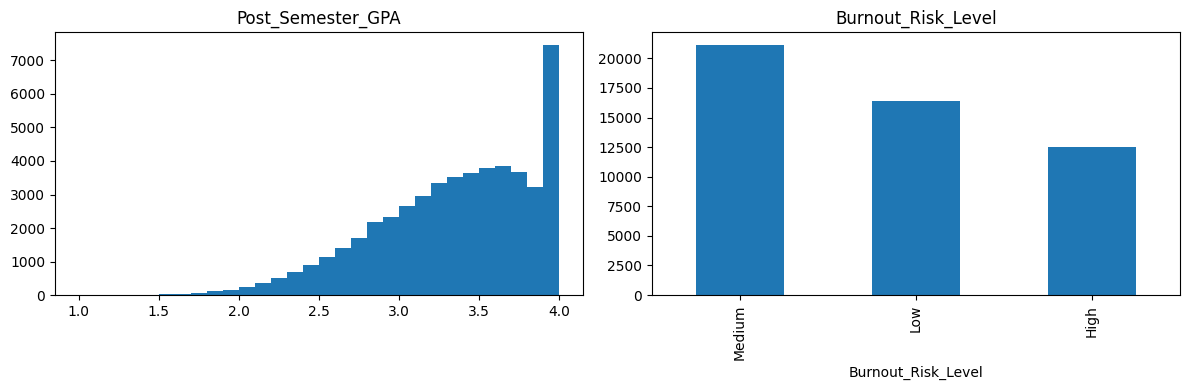

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['Post_Semester_GPA'], bins=30)
ax[0].set_title('Post_Semester_GPA')

df['Burnout_Risk_Level'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('Burnout_Risk_Level')

plt.tight_layout()
plt.show()

Кореляции

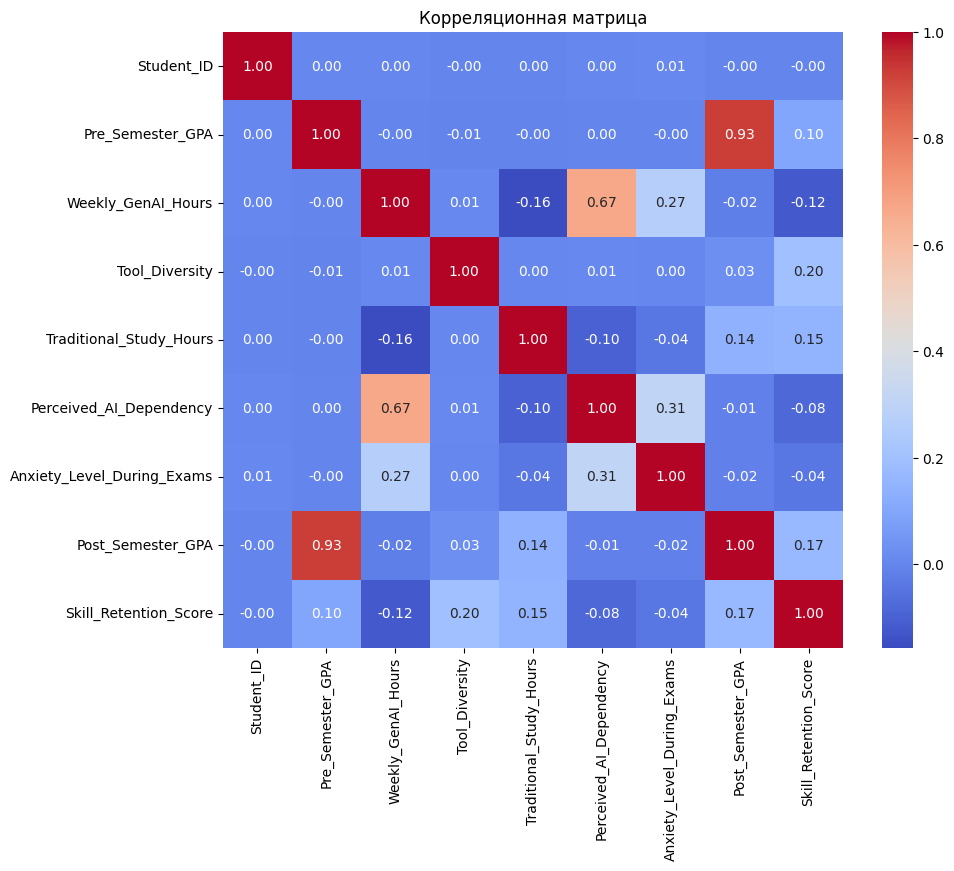

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

пропуски и выбросы

In [ ]:
df = df.copy()

# Пропуски: числовые -> медиана, категориальные -> мода
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# Выбросы через IQR (клиппинг)
num_cols = df.select_dtypes('number').columns
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print('Готово. Пропусков:', df.isnull().sum().sum())

Готово. Пропусков: 0


Кодирование категориальных признаков

In [ ]:
# Порядковые признаки
df['Year_of_Study'] = df['Year_of_Study'].map(
    {'Freshman':1,'Sophomore':2,'Junior':3,'Senior':4,'Graduate':5})
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].map(
    {'Beginner':1,'Intermediate':2,'Advanced':3})
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].map(
    {'Low':1,'Medium':2,'High':3})

# Номинальные -> One-Hot
df = pd.get_dummies(df, columns=['Major_Category','Primary_Use_Case','Institutional_Policy'])

# Бинарный
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)

print(df.shape)
df.head()

(50000, 26)


,Student_ID,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,...,Major_Category_Medical,Major_Category_STEM,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,100001,4,2.418,23.31,1,1,1,8.13,5.0,6,...,False,False,True,False,False,False,False,False,True,False
1,100002,3,3.821,1.12,3,5,0,16.65,3.0,9,...,True,False,False,False,False,True,False,False,True,False
2,100003,1,3.398,21.26,1,2,0,10.35,5.0,9,...,False,False,False,False,False,False,True,False,False,True
3,100004,4,3.789,1.82,2,4,0,15.23,2.0,2,...,False,False,True,False,False,False,False,False,True,False
4,100005,2,3.635,9.29,3,4,0,12.55,4.0,4,...,False,True,False,True,False,False,False,False,True,False


Новые признаки

In [ ]:
df['AI_Usage_Ratio'] = df['Weekly_GenAI_Hours'] / (df['Traditional_Study_Hours'] + 0.01)
df['Total_Study_Hours'] = df['Weekly_GenAI_Hours'] + df['Traditional_Study_Hours']
df['AI_Efficiency'] = df['Pre_Semester_GPA'] * df['Weekly_GenAI_Hours']
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']  # только для анализа!

print('Новые признаки добавлены:', ['AI_Usage_Ratio','Total_Study_Hours','AI_Efficiency','GPA_Change'])

Новые признаки добавлены: ['AI_Usage_Ratio', 'Total_Study_Hours', 'AI_Efficiency', 'GPA_Change']


Регрессия: подготовка данных

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Исключаем ID, целевые и GPA_Change
drop_cols = ['Student_ID', 'Post_Semester_GPA', 'Burnout_Risk_Level', 'GPA_Change']
X = df.drop(columns=drop_cols)
y = df['Post_Semester_GPA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Регрессия: обучение моделей

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def score(model, name):
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print(f"{name}: R2={r2_score(y_test,pred):.3f}, "
          f"RMSE={np.sqrt(mean_squared_error(y_test,pred)):.3f}, "
          f"MAE={mean_absolute_error(y_test,pred):.3f}")

score(LinearRegression(), 'Linear Regression')
score(KNeighborsRegressor(n_neighbors=5), 'KNN (k=5)')
score(DecisionTreeRegressor(max_depth=5, random_state=42), 'Decision Tree')
score(RandomForestRegressor(n_estimators=100, random_state=42), 'Random Forest')

Linear Regression: R2=0.896, RMSE=0.158, MAE=0.124
KNN (k=5): R2=0.717, RMSE=0.260, MAE=0.207
Decision Tree: R2=0.869, RMSE=0.176, MAE=0.137
Random Forest: R2=0.903, RMSE=0.152, MAE=0.119


Регрессия: график предсказаний

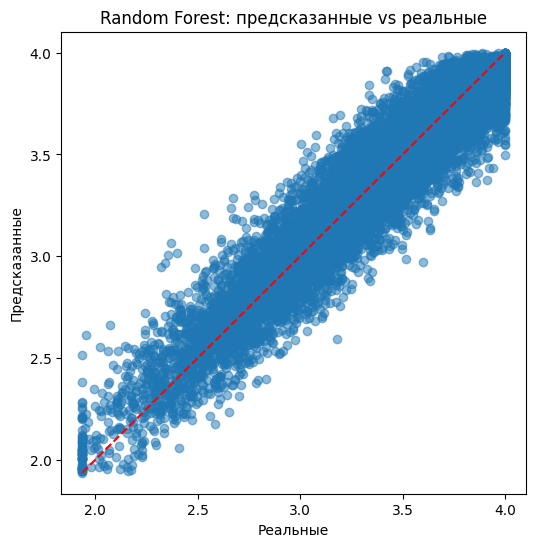

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_s, y_train)
pred = model.predict(X_test_s)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальные')
plt.ylabel('Предсказанные')
plt.title('Random Forest: предсказанные vs реальные')
plt.show()

Регрессия: KNN — подбор k

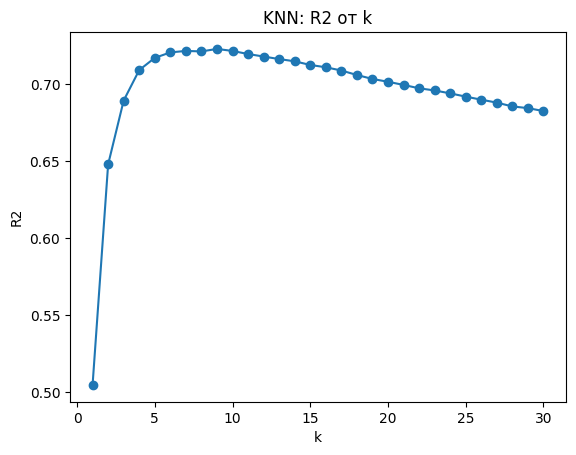

Лучшее k: 9 | R2 = 0.7227042179011678


In [ ]:
r2_list = []
for k in range(1, 31):
    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train_s, y_train)
    r2_list.append(r2_score(y_test, knn.predict(X_test_s)))

plt.plot(range(1, 31), r2_list, marker='o')
plt.xlabel('k')
plt.ylabel('R2')
plt.title('KNN: R2 от k')
plt.show()

best_k = range(1, 31)[int(np.argmax(r2_list))]
print('Лучшее k:', best_k, '| R2 =', max(r2_list))

Полиномиальные признаки

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train_s)
X_test_p = poly.transform(X_test_s)

lr_poly = LinearRegression().fit(X_train_p, y_train)
pred_p = lr_poly.predict(X_test_p)
print(f"Linear + Poly: R2={r2_score(y_test,pred_p):.3f}, "
      f"RMSE={np.sqrt(mean_squared_error(y_test,pred_p)):.3f}")

Linear + Poly: R2=0.910, RMSE=0.146


Классификация: подготовка

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Xc = df.drop(columns=drop_cols)
yc = df['Burnout_Risk_Level']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)

Классификация: Decision Tree и Random Forest

In [ ]:
def classify(model, name):
    model.fit(Xc_train_s, yc_train)
    pred = model.predict(Xc_test_s)
    print(f"\n=== {name} ===")
    print('Accuracy:', round(accuracy_score(yc_test, pred), 3))
    print('Confusion matrix:\n', confusion_matrix(yc_test, pred))
    print(classification_report(yc_test, pred, target_names=['Low','Medium','High']))

classify(DecisionTreeClassifier(max_depth=4, random_state=42), 'Decision Tree')
classify(RandomForestClassifier(n_estimators=100, random_state=42), 'Random Forest')


=== Decision Tree ===
Accuracy: 0.526
Confusion matrix:
 [[1930 1228  116]
 [1509 2141  579]
 [ 355  954 1188]]
              precision    recall  f1-score   support

         Low       0.51      0.59      0.55      3274
      Medium       0.50      0.51      0.50      4229
        High       0.63      0.48      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.54      0.52      0.53     10000
weighted avg       0.53      0.53      0.53     10000


=== Random Forest ===
Accuracy: 0.521
Confusion matrix:
 [[1637 1535  102]
 [1260 2425  544]
 [ 277 1068 1152]]
              precision    recall  f1-score   support

         Low       0.52      0.50      0.51      3274
      Medium       0.48      0.57      0.52      4229
        High       0.64      0.46      0.54      2497

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       0.53      0.52      0.52     10000



Кластеризация

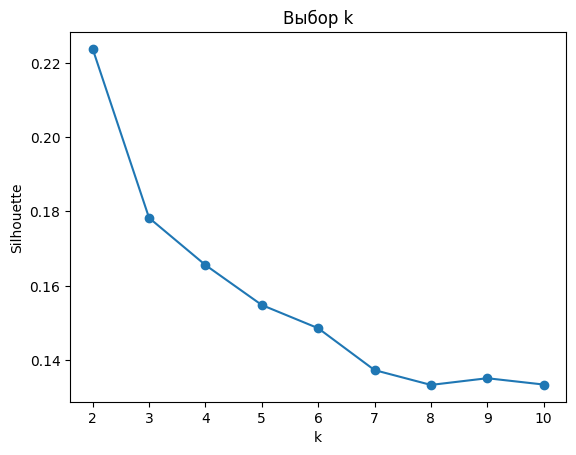

Оптимальное k: 2
Cluster
0    37084
1    12916
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_cols = ['Weekly_GenAI_Hours','Traditional_Study_Hours','Pre_Semester_GPA',
                'Skill_Retention_Score','Prompt_Engineering_Skill','Perceived_AI_Dependency']

Xc_cl = StandardScaler().fit_transform(df[cluster_cols])

# Подбор k по silhouette
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_cl)
    scores.append(silhouette_score(Xc_cl, km.labels_))

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Выбор k')
plt.show()

best_k = range(2, 11)[int(np.argmax(scores))]
print('Оптимальное k:', best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xc_cl)
df['Cluster'] = km.labels_
print(df['Cluster'].value_counts())

Переобучение Random Forest

In [ ]:
# Обновляем X и yc с новым признаком Cluster
X2 = df.drop(columns=drop_cols)
y2 = df['Post_Semester_GPA']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
sc2 = StandardScaler()
X2_train_s = sc2.fit_transform(X2_train)
X2_test_s = sc2.transform(X2_test)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X2_train_s, y2_train)
pred2 = rf2.predict(X2_test_s)

print('Random Forest с кластером:')
print('R2  =', round(r2_score(y2_test, pred2), 3))
print('RMSE=', round(np.sqrt(mean_squared_error(y2_test, pred2)), 3))
print('\n(Сравните с предыдущим RF без кластера)')

Random Forest с кластером:
R2  = 0.903
RMSE= 0.152

(Сравните с предыдущим RF без кластера)
